# GPSR + LUME-Cheetah Virtual Accelerator Example

**Goal of the example:** Reconstruct a beam's 6D phase space from measured screen
images, by tracking a *trainable* beam generator through a *differentiable, frozen* LUME-Cheetah virtual accelerator until the simulated images match the measurements.

1. Load the measurements `GPSRLUMEDataModule`. Run `datamodule.ipynb` first.
2. Assemble a `GPSRLUMEModel` composed by a `BeamGenerator` (trainable beam generator at reconstruction point), and a `LUMECheetahModel` (frozen virtual accelerator which tracks from reconstruction point to observations).
3. Create the trainable `LitGPSRLUME` PyTorch Lightning module composed by the `GPSRLUMEModel` and training hyperparameters.
4. Fit an untrained beam using PyTorch Lightning API.
5. Show reconstructed beam, compare predictions with observations.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch

import lightning as L
from lightning.pytorch.loggers import CSVLogger

from gpsr.beams import NNParticleBeamGenerator
from gpsr.train import EpochLossPrinter
from gpsr.losses import mae_loss

# gpsr.lume is the new package with support of
# LUME-Cheetah models and new PV-based data modules
from gpsr.lume.data import GPSRLUMEDataModule
from gpsr.lume.model import GPSRLUMEModel
from gpsr.lume.training import LitGPSRLUME
from gpsr.lume.plotting import plot_beam_distribution, plot_multi_source_images
from gpsr.lume.predicting import predict_multi_source_images

In [2]:
# example root directory. Change if needed
EXAMPLE_ROOT = "/sdf/home/j/jpga/repos/gpsr/docs/examples/lume"

In [3]:
# seed for reproducibility
SEED = 1
L.seed_everything(SEED, workers=True)

[rank: 0] Seed set to 1


1

## 1. Load `GPSRLUMEDataModule` (training data)

The datamodule is written in `data_module.ipynb`. Run that first.

`GPSRLUMEDataModule` is the training data to fit the beam distribution of the `GPSRLUMEModel`. Consists
of various `GPSRLUMEDataset`, each corresponding to quad scan data. The data is indexed by PV names.

In [4]:
# load training data GPSRLUMEDataModule
datamodule = GPSRLUMEDataModule.load(
    os.path.join(EXAMPLE_ROOT, "datasets", "gpsr_lume_datamodule.pt")
)

In [5]:
# inspect the GPSRLUMEDataModule
datamodule

GPSRLUMEDataModule(
  batch_size=full, num_workers=0, pin_memory=False
  sources: ['S1_tdc_off', 'S1_tdc_on', 'S2_tdc_off', 'S2_tdc_on']
  datasets:
    [S1_tdc_off] GPSRLUMEDataset(n_samples=7)
        Data: TensorDict(
          fields={
              beamline_settings: TensorDict(
                  fields={
                      Q2:BCTRL: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
                      TDC:AREQ: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False),
              observations: TensorDict(
                  fields={
                      S1:Image:ArrayData: Tensor(shape=torch.Size([7, 200, 400]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False)},
          batch_size=torch.Size([

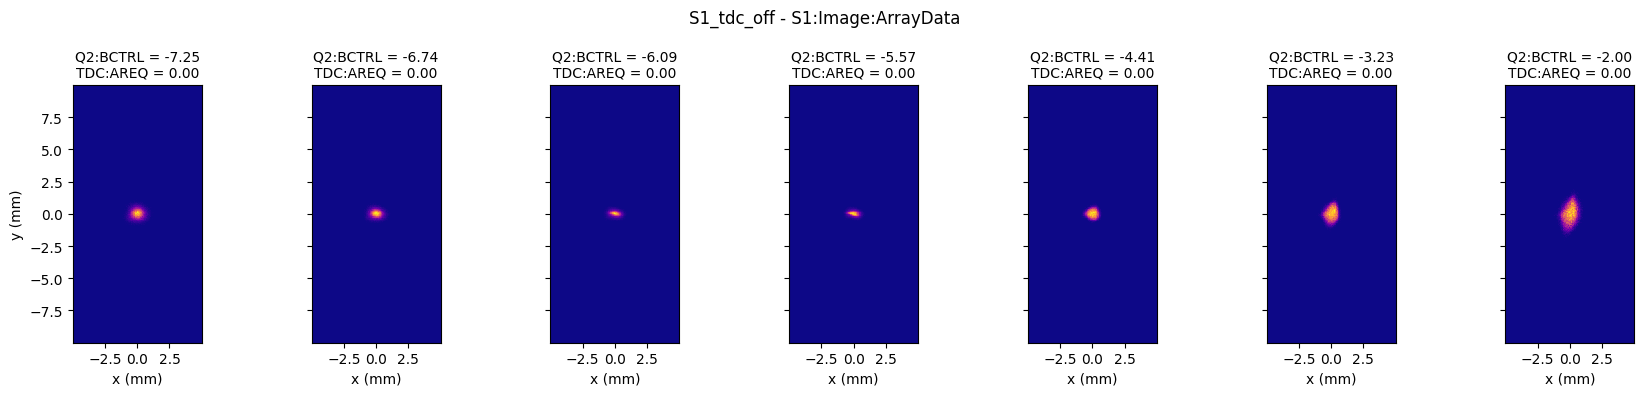

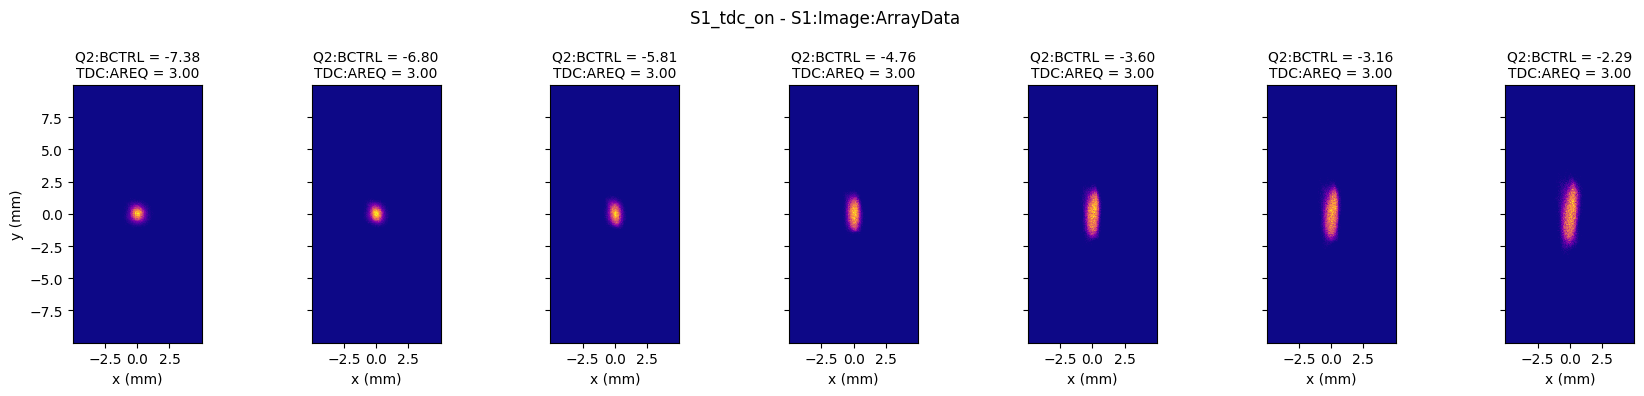

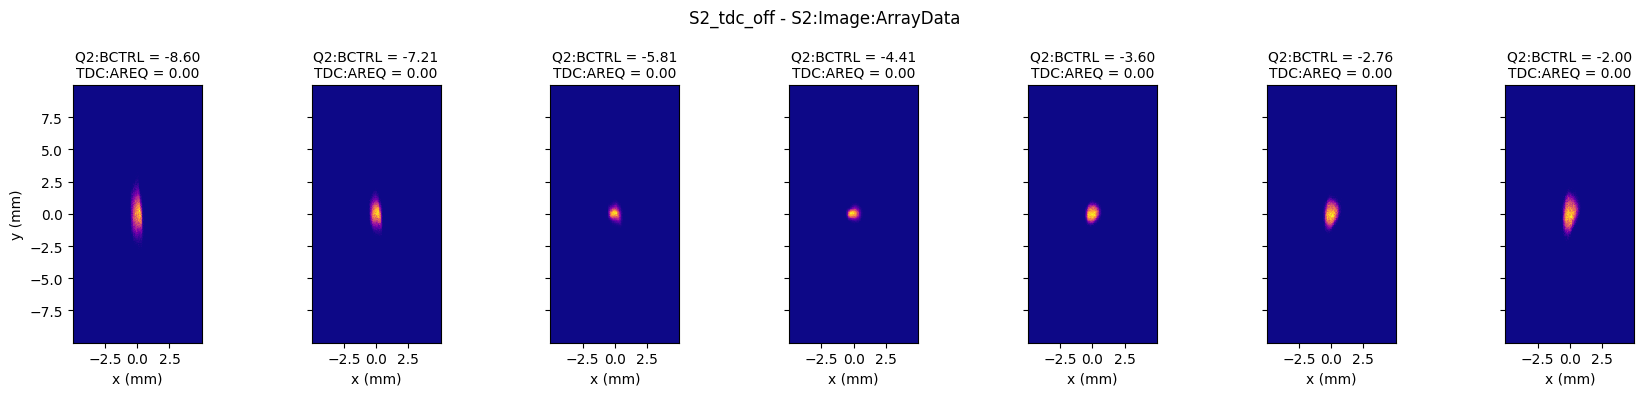

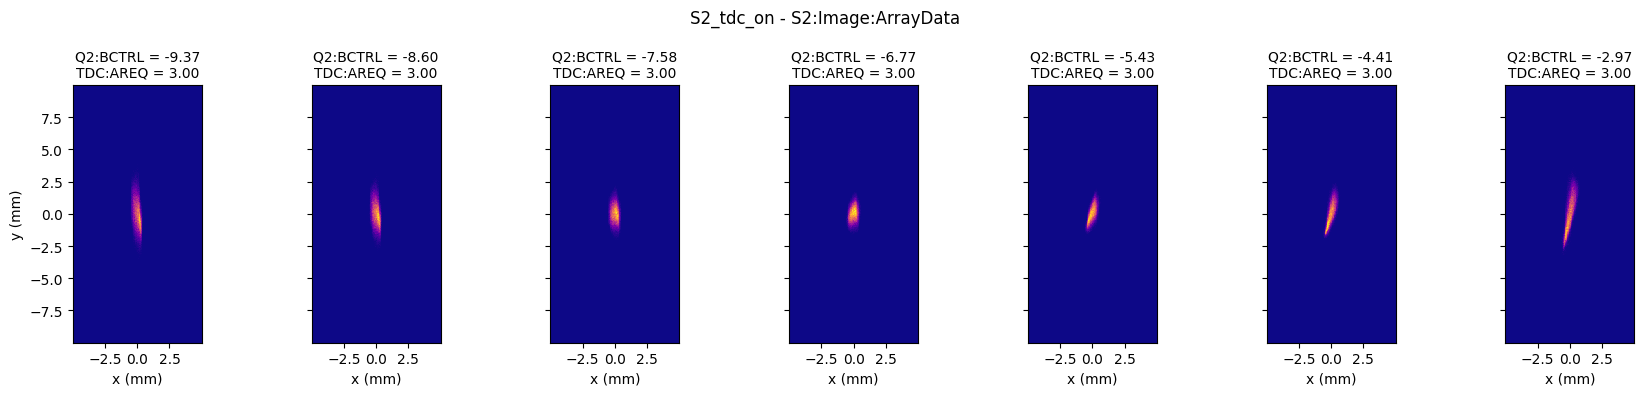

In [6]:
# plot screen images from all quad scans in the GPSRLUMEDataModule
figures = plot_multi_source_images(
    images=datamodule.to_observations(),
    sources_spec=datamodule.to_sources_spec(),
    pcolormesh_kwargs={"cmap": "plasma"},
    normalize_each=True,
)

## 2. Assemble `GPSRLUMEModel` (trainable model)

`GPSRLUMEModel` consists of a `BeamGenerator` (trainable beam generator at reconstruction point), and a `LUMECheetahModel` (frozen virtual accelerator which tracks from reconstruction point to observations).

In [7]:
# example virtual accelerator package which builds the LUMECheetahModel.
# each facility should have its own virtual accelerator package
example_va_dir = os.path.join(EXAMPLE_ROOT, "example_virtual_accelerator")
sys.path.insert(0, os.path.dirname(example_va_dir))
from example_virtual_accelerator.factory import ( # noqa: E402
    BUILDER_IMPORT_PATH, 
    build_accelerator
)

In [8]:
DESIGN_ENERGY = 125.0e6 # reference energy in eV shared by beam generator and lume cheetah model
LATTICE_PATH = os.path.join(
    EXAMPLE_ROOT, "example_virtual_accelerator/lattice_6d.json"
) # path to the cheetah lattice JSON file.

# LUMECheetahModel (frozen): VA built from json lattice and VA builder function
lume_cheetah_model = build_accelerator(
    lattice=LATTICE_PATH, 
    energy=DESIGN_ENERGY
)

# BeamGenerator (trainable): NN beam generator at reconstruction point
beam_generator = NNParticleBeamGenerator(
    n_particles=10_000,
    energy=DESIGN_ENERGY,
    n_dim=6,
)

# GPSRLUMEModel: composed by the frozen LUMECheetahModel and trainable BeamGenerator
gpsr_lume_model = GPSRLUMEModel(
    lume_cheetah_model=lume_cheetah_model,
    beam_generator=beam_generator,
    accelerator_spec={  # specs necesasary for serializable checkpointing
        "builder": BUILDER_IMPORT_PATH,
        "config": {"lattice": LATTICE_PATH},  
    },
)

In [9]:
print("PV interface of the virtual accelerator:")
for pv_name in sorted(lume_cheetah_model.supported_variables):
    print("   ", pv_name)

PV interface of the virtual accelerator:
    Q1:BCTRL
    Q2:BCTRL
    Q3:BCTRL
    Q4:BCTRL
    S1:Image:ArrayData
    S2:Image:ArrayData
    TDC:AREQ
    TDC:PREQ


## 3. Create `LitGPSRLUME` module (PyTorch Lightning module for training)

`LitGPSRLUME` is the PyTorch Lightning training object composed by the `GPSRLUMEModel` and training hyperparameters.

In [10]:
# LitGPSRLUME: LightningModule that wraps the GPSRLUMEModel and adds training logic.
lit_model = LitGPSRLUME(
    gpsr_lume_model=gpsr_lume_model, 
    lr=1e-3, 
    loss_func=mae_loss
)

In [11]:
print(
    "\ntrainable parameters:",
    sum(p.numel() for p in lit_model.parameters() if p.requires_grad),
)


trainable parameters: 1106


## 4. Phase space fitting (training)

Fit an untrained beam using PyTorch Lightning API.

In [12]:
# seed reconstruction
L.seed_everything(SEED, workers=True)

# initialize the logger
logger = CSVLogger(
    save_dir=EXAMPLE_ROOT, 
    name="logs",
    version="version_11"
)

# create lightning trainer. Uses GPU if available
trainer = L.Trainer(
    max_epochs=1000,
    devices=1,
    logger=logger,
    enable_checkpointing=False,  # next section shows checkpointing explicitly
    log_every_n_steps=1,
    enable_progress_bar=False,
    callbacks=[EpochLossPrinter(every_n_epochs=100, metric="loss")],
)

[rank: 0] Seed set to 1
/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/torch/cuda/__init__.py:991: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [13]:
# fit model
trainer.fit(lit_model, datamodule=datamodule)

/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory /sdf/home/j/jpga/repos/gpsr/docs/examples/lume/logs/version_11 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gpsr_lume_model │ GPSRLUMEModel │  1.1 K │ train │     0 │
└───┴─────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 57                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.
/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


epoch     0/1000 | loss=2.37e-05
epoch   100/1000 | loss=3.45e-06
epoch   200/1000 | loss=3.13e-06
epoch   300/1000 | loss=2.94e-06
epoch   400/1000 | loss=3.02e-06
epoch   500/1000 | loss=2.76e-06
epoch   600/1000 | loss=2.76e-06
epoch   700/1000 | loss=2.76e-06
epoch   800/1000 | loss=2.66e-06
epoch   900/1000 | loss=2.65e-06


`Trainer.fit` stopped: `max_epochs=1000` reached.


epoch   999/1000 | loss=2.61e-06


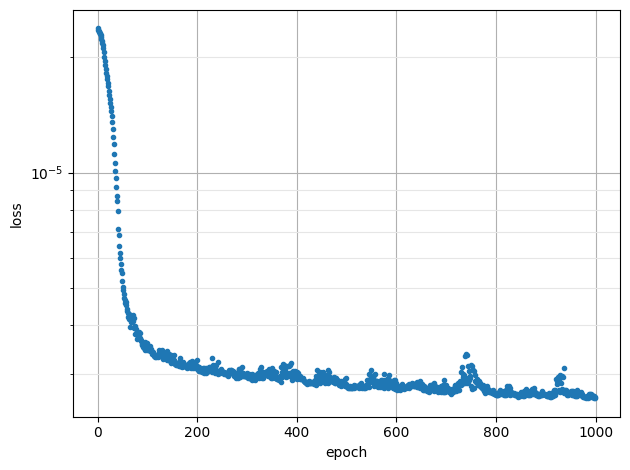

In [14]:
# show loss vs epoch
logs = np.genfromtxt(
    os.path.join(EXAMPLE_ROOT, "logs", "version_11", "metrics.csv"), 
    delimiter=",", 
    names=True
)
fig, ax = plt.subplots()
ax.plot(logs["epoch"], logs["loss_epoch"], marker=".")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_yscale("log")
ax.grid()
ax.grid(which="minor", color="0.9")
plt.tight_layout()

## 5. Results

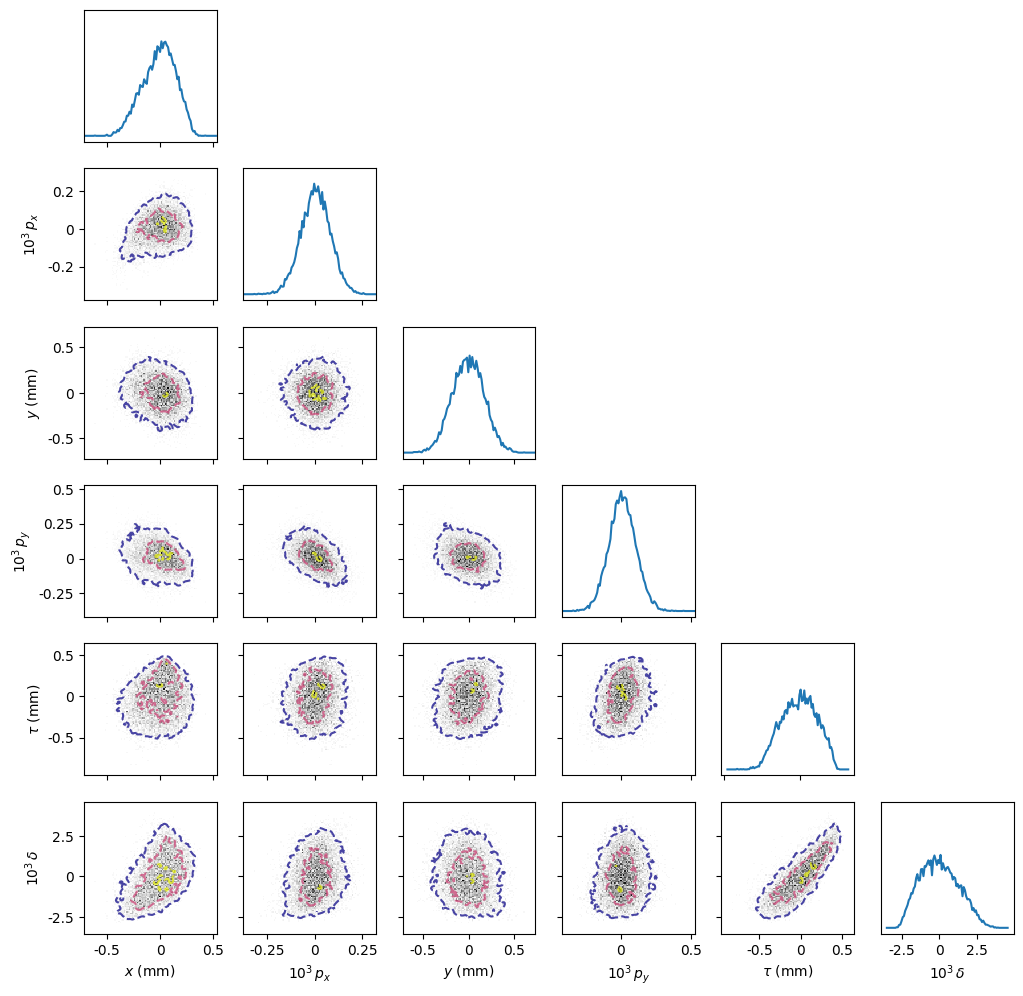

In [15]:
# plot reconstructed beam corner plot
reconstructed_beam = lit_model.gpsr_lume_model.beam_generator()
fig, axes = plot_beam_distribution(reconstructed_beam)

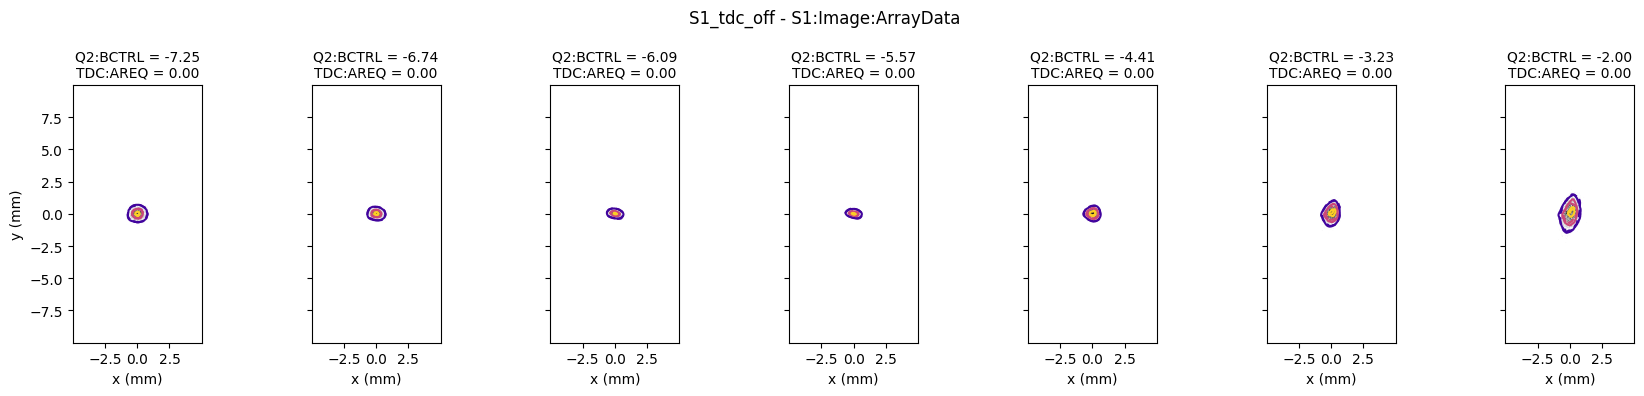

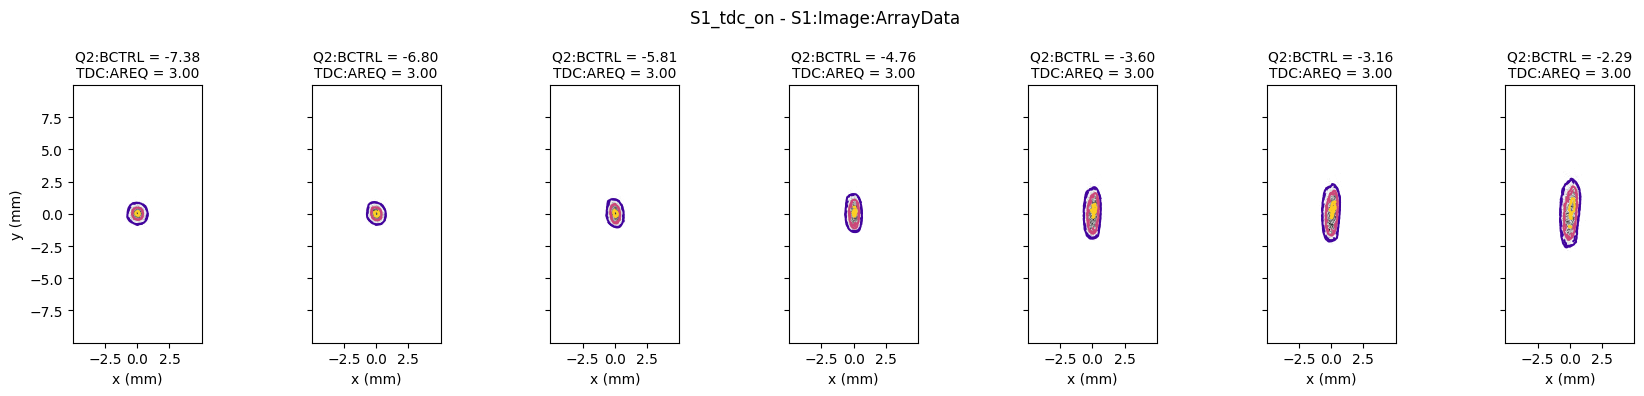

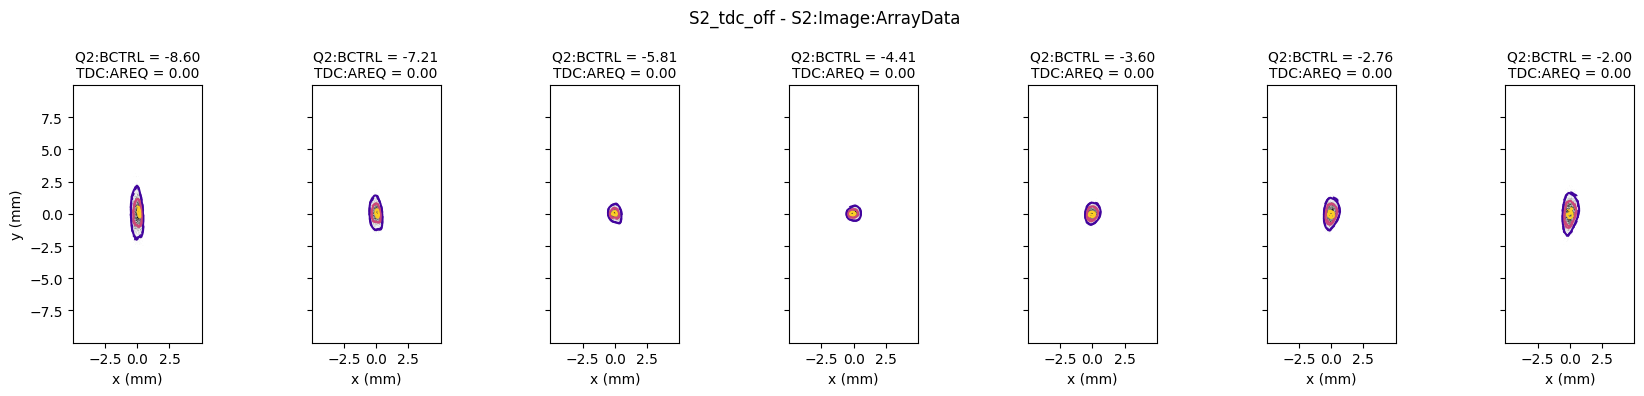

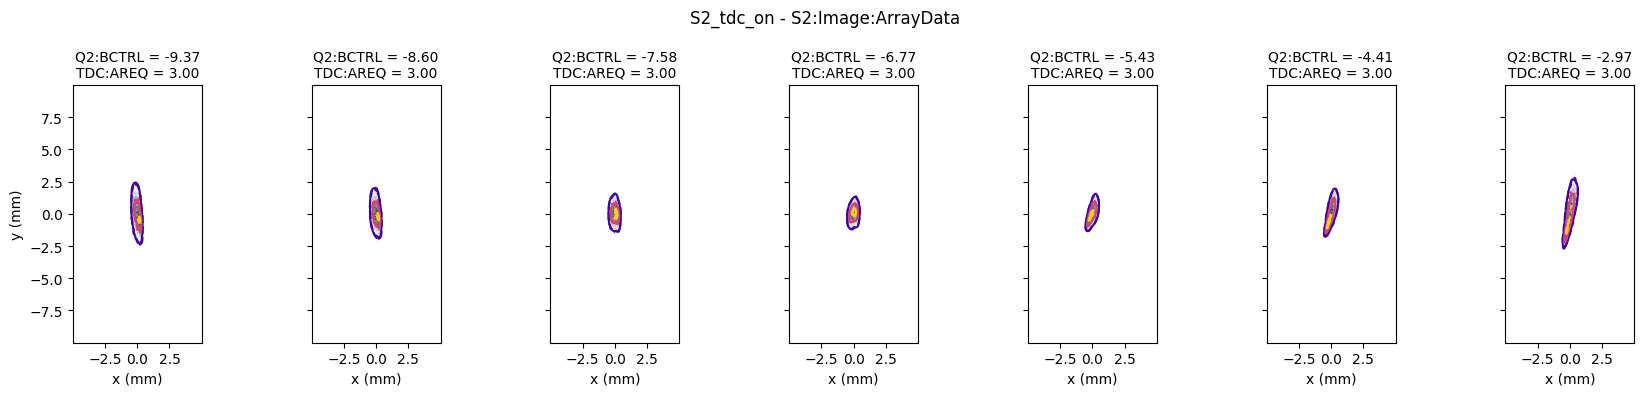

In [17]:
# Plot predicted images vs measurements. 
predicted_images = predict_multi_source_images(
    model=lit_model, sources_spec=datamodule.to_sources_spec()
)
figures = plot_multi_source_images(
    images=predicted_images,
    sources_spec=datamodule.to_sources_spec(),
    overlay_images=datamodule.to_observations(),
    contours=True,
)

## Note: checkpoints are self-contained

A checkpoint stores two things: the trained beam generator's weights, and a **spec**
-- a recipe for rebuilding the accelerator, written with nothing but strings, numbers
and plain dicts. The frozen accelerator's own tensors are not stored; they get rebuilt
from the recipe instead.

That keeps the file portable and safe to open: it loads with
`torch.load(..., weights_only=True)`, which unpickles nothing, and
`LitGPSRLUME.load_self_contained` needs the file and nothing else -- no lattice, no
measurements, no code from this notebook. The `accelerator_spec` given to
`GPSRLUMEModel` in step 2 is what makes this possible.

(The lattice is stored as JSON *text* read back from the live accelerator, not as the
path passed in above, so calibration applied after the build is captured too.)

In [18]:
# save the checkpoint, then read it back as plain data
CHECKPOINT_PATH = os.path.join(EXAMPLE_ROOT, "example_reconstruction.ckpt")
trainer.save_checkpoint(CHECKPOINT_PATH)

checkpoint = torch.load(CHECKPOINT_PATH, weights_only=True)
spec = checkpoint["gpsr_lume_spec"]

print("accelerator builder:", spec["accelerator"]["builder"])
print(
    "lattice            :",
    len(spec["accelerator"]["config"]["lattice"]),
    "chars of JSON",
)
print("beam generator     :", spec["generator"]["cls"])
print("generator config   :", spec["generator"]["config"])
print("saved weights      :", sorted(checkpoint["state_dict"]))

`weights_only` was not set, defaulting to `False`.


accelerator builder: example_virtual_accelerator.factory.build_accelerator
lattice            : 3110 chars of JSON
beam generator     : gpsr.beams.NNParticleBeamGenerator
generator config   : {'n_particles': 10000, 'energy': 125000000.0, 'output_scale': 0.01, 'n_dim': 6}
saved weights      : ['gpsr_lume_model.beam_generator.base_particles', 'gpsr_lume_model.beam_generator.beam_energy', 'gpsr_lume_model.beam_generator.particle_charges', 'gpsr_lume_model.beam_generator.survival_probabilities', 'gpsr_lume_model.beam_generator.transformer.output_scale', 'gpsr_lume_model.beam_generator.transformer.stack.0.bias', 'gpsr_lume_model.beam_generator.transformer.stack.0.weight', 'gpsr_lume_model.beam_generator.transformer.stack.2.bias', 'gpsr_lume_model.beam_generator.transformer.stack.2.weight', 'gpsr_lume_model.beam_generator.transformer.stack.5.bias', 'gpsr_lume_model.beam_generator.transformer.stack.5.weight', 'gpsr_lume_model.beam_generator.transformer.stack.8.bias', 'gpsr_lume_model.beam_gen

In [19]:
# rebuild from the checkpoint alone: the accelerator from the spec, the beam
# generator from the saved weights. The facility package only has to be importable,
# since the builder is named by its import path.
reloaded_model = LitGPSRLUME.load_self_contained(CHECKPOINT_PATH, map_location="cpu")

# the rebuilt model makes the same predictions as the fitted one
reloaded_predictions = predict_multi_source_images(
    model=reloaded_model, sources_spec=datamodule.to_sources_spec()
)
identical = all(
    torch.allclose(predicted_images[source][pv], reloaded_predictions[source][pv])
    for source in predicted_images
    for pv in predicted_images[source]
)
print("reloaded model reproduces the predictions exactly:", identical)

reloaded model reproduces the predictions exactly: True


/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:193: Found keys that are in the model state dict but not in the checkpoint: ['gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.0.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.voltage', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.phase', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.frequency', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.misalignment', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.tilt', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.2.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.3.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.3.k1', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elemen

In [20]:
# Continue the fit from the checkpoint for another 100 epochs.
#
# `ckpt_path=` restores the optimizer state and the epoch counter, not just the
# weights, so max_epochs keeps counting from where the last fit stopped: ask for
# 100 *more* than it reached, not for 100.
resumed_model = LitGPSRLUME.load_self_contained(CHECKPOINT_PATH)

resumed_trainer = L.Trainer(
    max_epochs=checkpoint["epoch"] + 100,
    devices=1,
    logger=CSVLogger(save_dir=EXAMPLE_ROOT, name="logs", version="version_1"),
    enable_checkpointing=False,
    log_every_n_steps=1,
    enable_progress_bar=False,
    callbacks=[EpochLossPrinter(every_n_epochs=100, metric="loss")],
)
resumed_trainer.fit(resumed_model, datamodule=datamodule, ckpt_path=CHECKPOINT_PATH)

# the longer fit checkpoints the same way, and reloads the same way
resumed_trainer.save_checkpoint(
    os.path.join(EXAMPLE_ROOT, "example_reconstruction_resumed.ckpt")
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory /sdf/home/j/jpga/repos/gpsr/docs/examples/lume/logs/version_1 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
Restoring states from the checkpoint path at /sdf/home/j/jpga/repos/gpsr/docs/examples/lume/example_reconstruction.ckpt


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gpsr_lume_model │ GPSRLUMEModel │  1.1 K │ train │     0 │
└───┴─────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 57                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at /sdf/home/j/jpga/repos/gpsr/docs/examples/lume/example_reconstruction.ckpt
SLURM auto-requeueing enabled. Setting signal handlers.


epoch  1000/1100 | loss=2.64e-06


`Trainer.fit` stopped: `max_epochs=1100` reached.
`weights_only` was not set, defaulting to `False`.


epoch  1099/1100 | loss=2.60e-06


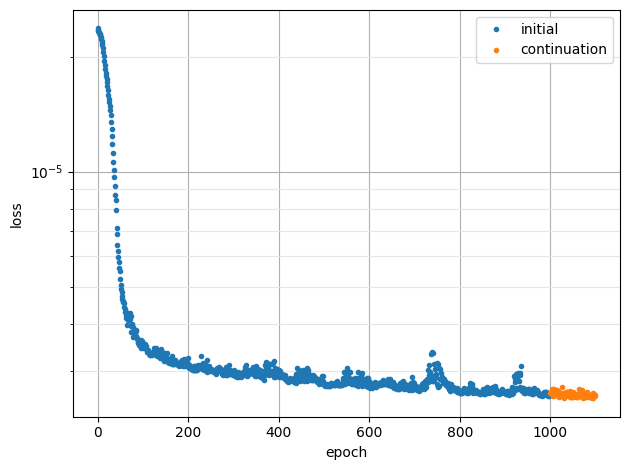

In [21]:
# show loss vs epoch
logs_2 = np.genfromtxt(
    os.path.join(EXAMPLE_ROOT, "logs", "version_1", "metrics.csv"), 
    delimiter=",", 
    names=True
)
fig, ax = plt.subplots()
ax.plot(logs["epoch"], logs["loss_epoch"], ".", label='initial')
ax.plot(logs_2["epoch"], logs_2["loss_epoch"], ".", label='continuation')
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_yscale("log")
ax.grid()
ax.grid(which="minor", color="0.9")
ax.legend()
plt.tight_layout()